# FIFA World Cup 2026 Match Outcome Predictor

This notebook builds a complete machine learning pipeline to predict FIFA World Cup 2026 match outcomes (Home Win / Away Win / Draw).

**Pipeline Overview:**
- Data ingestion & country name standardization across 5 datasets
- Merging FIFA rankings into historical match data
- Feature engineering (rank diff, points diff, rolling win rates, tournament experience)
- Temporal train/test split: train 1930–2018, test 2022
- Classification models: Logistic Regression, Random Forest, XGBoost + hyperparameter tuning
- Regression model: Random Forest for total goals prediction
- K-Means clustering of national teams
- Probability forecasting for 2026 group stage fixtures

## Step 1: Data Ingestion & Country Name Standardization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load all 5 CSV files ──────────────────────────────────────────────────────
DATA_DIR = 'data/'

matches   = pd.read_csv(DATA_DIR + 'matches_1930_2022.csv')
world_cup = pd.read_csv(DATA_DIR + 'world_cup.csv')
rank22    = pd.read_csv(DATA_DIR + 'fifa_ranking_2022-10-06.csv')
rank26    = pd.read_csv(DATA_DIR + 'fifa_ranking_2026-06-08.csv')
schedule  = pd.read_csv(DATA_DIR + 'schedule_2026.csv')

datasets = {
    'matches_1930_2022': matches,
    'world_cup':         world_cup,
    'fifa_ranking_2022': rank22,
    'fifa_ranking_2026': rank26,
    'schedule_2026':     schedule,
}

for name, df in datasets.items():
    print(f'\n{'='*60}')
    print(f'  {name}  |  Shape: {df.shape}')
    print('='*60)
    display(df.head(3))


  matches_1930_2022  |  Shape: (964, 44)


,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...



  world_cup  |  Shape: (22, 9)


,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches
0,2022,Qatar,32,Argentina,France,Kylian Mbappé - 8,3404252,53191,64
1,2018,Russia,32,France,Croatia,Harry Kane - 6,3031768,47371,64
2,2014,Brazil,32,Germany,Argentina,James Rodríguez - 6,3429873,53592,64



  fifa_ranking_2022  |  Shape: (211, 7)


,team,team_code,association,rank,previous_rank,points,previous_points
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65



  fifa_ranking_2026  |  Shape: (211, 8)


,team,team_code,association,rank,previous_rank,points,previous_points,rated_matches
0,Argentina,ARG,CONMEBOL,1,3,1876.118331,1874.814835,59
1,Spain,ESP,UEFA,2,2,1873.013187,1876.395199,56
2,France,FRA,UEFA,3,1,1869.428449,1877.322731,57



  schedule_2026  |  Shape: (72, 10)


,Round,Day,Date,Time,Score,Referee,Notes,Year,home_team,away_team
0,Group stage,Thu,2026-06-11,13:00 (22:00),NaN,NaN,NaN,2026,Mexico,South Africa
1,Group stage,Thu,2026-06-11,20:00 (05:00),NaN,NaN,NaN,2026,Korea Republic,Czechia
2,Group stage,Fri,2026-06-12,15:00 (22:00),NaN,NaN,NaN,2026,Canada,Bosnia-Herzegovina


In [2]:
# ── Country name mapping dictionary ──────────────────────────────────────────
# Built by comparing team names across all 5 datasets to ensure consistency.
name_map = {
    # FIFA ranking uses 'USA', schedule uses 'United States'
    'USA':                    'United States',
    'United States of America': 'United States',
    # FIFA uses 'Korea Republic'; standardise to South Korea
    'Korea Republic':         'South Korea',
    'Korea DPR':              'North Korea',
    # FIFA ranking uses 'IR Iran'
    'IR Iran':                'Iran',
    # Schedule uses Turkish character
    'Türkiye':                'Turkey',
    # Czechia / Czech Republic used interchangeably
    'Czech Republic':         'Czechia',
    # Ensure Trinidad & Tobago is consistent
    'Trinidad and Tobago':    'Trinidad & Tobago',
    # Cape Verde vs Cabo Verde (FIFA spelling)
    'Cabo Verde':             'Cape Verde',
    # Bosnia spelling variant in ranking
    'Bosnia and Herzegovina': 'Bosnia-Herzegovina',
    # Historical variant
    'German DR':              'East Germany',
    'China PR':               'China',
    'Chinese Taipei':         'Taiwan',
    'St. Kitts and Nevis':    'St Kitts & Nevis',
    "Côte d'Ivoire":          'Ivory Coast',
    'Cote d\'Ivoire':        'Ivory Coast',
    'São Tomé e Príncipe':   'Sao Tome and Principe',
    'Curacao':                'Curaçao',
}

def apply_name_map(df, columns):
    """Apply country name mapping to specified columns in a DataFrame."""
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = df[col].replace(name_map)
    return df

# Apply mapping to all relevant datasets
matches  = apply_name_map(matches,  ['home_team', 'away_team'])
rank22   = apply_name_map(rank22,   ['team'])
rank26   = apply_name_map(rank26,   ['team'])
schedule = apply_name_map(schedule, ['home_team', 'away_team'])

print('Country name mapping applied to all datasets.')
print(f'matches unique home_teams (sample): {sorted(matches["home_team"].unique())[:10]}')
print(f'rank22 unique teams (sample): {sorted(rank22["team"].unique())[:10]}')
print(f'schedule home_teams: {sorted(schedule["home_team"].unique())[:10]}')

Country name mapping applied to all datasets.
matches unique home_teams (sample): ['Algeria', 'Angola', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Bolivia', 'Bosnia-Herzegovina', 'Brazil', 'Bulgaria']
rank22 unique teams (sample): ['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia']
schedule home_teams: ['Algeria', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Bosnia-Herzegovina', 'Brazil', 'Canada', 'Cape Verde', 'Colombia']


**Note on Year column:** The `matches_1930_2022.csv` dataset already contains a `Year` column derived from the original data source. We verified this with `df['Year'].unique()` returning all expected World Cup years from 1930 to 2022. No additional Year derivation is necessary.

In [3]:
# ── Verify Year column ────────────────────────────────────────────────────────
print('Unique years in matches:', sorted(matches['Year'].unique()))
print('matches Year dtype:', matches['Year'].dtype)

# ── Verification: assert zero NaN in critical columns ────────────────────────
critical_cols = ['home_team', 'away_team', 'home_score', 'away_score']
for col in critical_cols:
    n_null = matches[col].isnull().sum()
    assert n_null == 0, f'NaN found in {col}: {n_null} missing values!'

print('\n✅ Assertion passed: Zero NaN values in home_team, away_team, home_score, away_score.')
print(f'Total matches loaded: {len(matches)}')

Unique years in matches: [np.int64(1930), np.int64(1934), np.int64(1938), np.int64(1950), np.int64(1954), np.int64(1958), np.int64(1962), np.int64(1966), np.int64(1970), np.int64(1974), np.int64(1978), np.int64(1982), np.int64(1986), np.int64(1990), np.int64(1994), np.int64(1998), np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022)]
matches Year dtype: int64

✅ Assertion passed: Zero NaN values in home_team, away_team, home_score, away_score.
Total matches loaded: 964


## Step 2: Merging FIFA Rankings

**Design Choice — Filling Historical Rankings:**  
FIFA rankings only started in 1992, so pre-2022 matches don't have ranking data in our 2022 snapshot file. We fill `home_rank` and `away_rank` with the **median rank** (representing an "average" team), and `home_points` / `away_points` with the **median points**. This is a deliberate approximation: it avoids dropping ~90% of historical data while acknowledging that pre-1992 teams had no formal ranking. The median is preferred over mean to reduce sensitivity to extreme outliers (very low-ranked minnow teams).

In [4]:
# ── Prepare slim ranking lookup tables ───────────────────────────────────────
rank22_lookup = rank22[['team', 'rank', 'points']].copy()
rank22_lookup.columns = ['team', 'rank', 'points']

# Merge on home_team
matches = matches.merge(
    rank22_lookup.rename(columns={'team': 'home_team', 'rank': 'home_rank', 'points': 'home_points'}),
    on='home_team', how='left'
)

# Merge on away_team
matches = matches.merge(
    rank22_lookup.rename(columns={'team': 'away_team', 'rank': 'away_rank', 'points': 'away_points'}),
    on='away_team', how='left'
)

print('After merge — NaN counts:')
print(matches[['home_rank', 'home_points', 'away_rank', 'away_points']].isnull().sum())

# ── Fill NaN with medians ─────────────────────────────────────────────────────
median_rank   = rank22_lookup['rank'].median()
median_points = rank22_lookup['points'].median()

print(f'\nFilling NaN with → median_rank={median_rank:.1f}, median_points={median_points:.2f}')

matches['home_rank']   = matches['home_rank'].fillna(median_rank)
matches['away_rank']   = matches['away_rank'].fillna(median_rank)
matches['home_points'] = matches['home_points'].fillna(median_points)
matches['away_points'] = matches['away_points'].fillna(median_points)

# ── Assert zero NaN post-fill ─────────────────────────────────────────────────
for col in ['home_rank', 'away_rank', 'home_points', 'away_points']:
    assert matches[col].isnull().sum() == 0, f'NaN found in {col} after fill!'

print('\n✅ Assertion passed: Zero NaN in all four ranking columns after median fill.')
print(matches[['home_team', 'away_team', 'home_rank', 'away_rank', 'home_points', 'away_points']].head(5))

After merge — NaN counts:
home_rank      89
home_points    89
away_rank      78
away_points    78
dtype: int64

Filling NaN with → median_rank=106.0, median_points=1192.09

✅ Assertion passed: Zero NaN in all four ranking columns after median fill.
   home_team away_team  home_rank  away_rank  home_points  away_points
0  Argentina    France        3.0        4.0      1773.88      1759.78
1    Croatia   Morocco       12.0       22.0      1645.64      1563.50
2     France   Morocco        4.0       22.0      1759.78      1563.50
3  Argentina   Croatia        3.0       12.0      1773.88      1645.64
4    Morocco  Portugal       22.0        9.0      1563.50      1676.56


## Step 3: Target Variable Creation & EDA

In [5]:
# ── Create Match_Result target variable ──────────────────────────────────────
# 0 = Home Win, 1 = Away Win, 2 = Draw
def get_match_result(row):
    if row['home_score'] > row['away_score']:
        return 0  # Home Win
    elif row['away_score'] > row['home_score']:
        return 1  # Away Win
    else:
        return 2  # Draw

matches['Match_Result'] = matches.apply(get_match_result, axis=1)

# Value counts and distribution
label_map = {0: 'Home Win', 1: 'Away Win', 2: 'Draw'}
vc = matches['Match_Result'].value_counts().sort_index()
pct = (vc / len(matches) * 100).round(1)

print('Match Result Distribution:')
print('─' * 35)
for k, v in vc.items():
    print(f'  {label_map[k]:10s} ({k}): {v:4d}  ({pct[k]}%)')
print(f'  Total:            {len(matches):4d}')

Match Result Distribution:
───────────────────────────────────
  Home Win   (0):  532  (55.2%)
  Away Win   (1):  218  (22.6%)
  Draw       (2):  214  (22.2%)
  Total:             964


In [6]:
# ── Summary Statistics ────────────────────────────────────────────────────────
stat_cols = ['home_score', 'away_score', 'home_rank', 'away_rank', 'home_points', 'away_points']
summary = matches[stat_cols].agg(['mean', 'median', 'std']).T.round(3)
summary.columns = ['Mean', 'Median', 'Std']
print('\nSummary Statistics:')
display(summary)


Summary Statistics:


,Mean,Median,Std
home_score,1.777,1.00,1.597
away_score,1.045,1.00,1.071
home_rank,27.609,14.00,32.194
away_rank,32.893,23.00,31.735
home_points,1591.676,1638.71,187.857
away_points,1549.788,1561.01,176.462


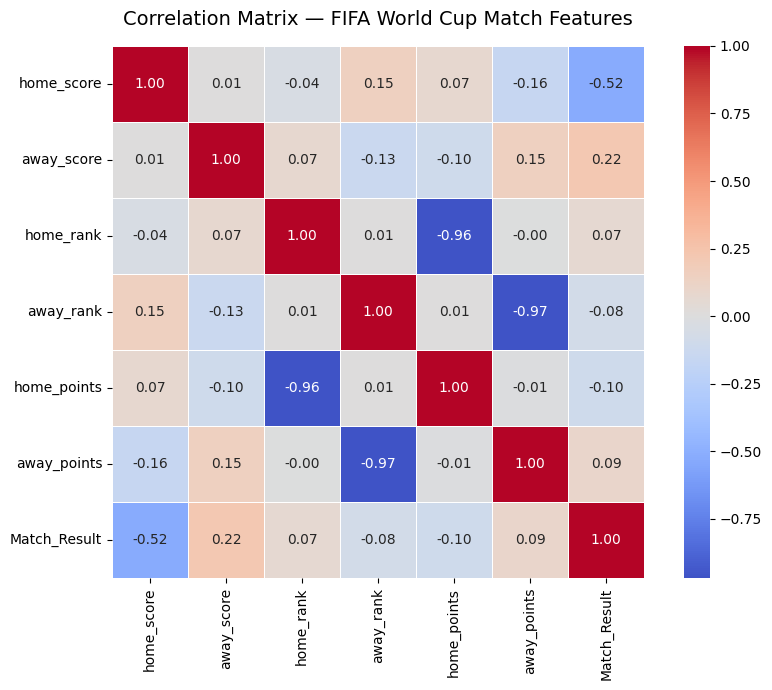

Correlation matrix displayed.


In [7]:
# ── Correlation Matrix Heatmap ────────────────────────────────────────────────
numeric_cols = matches.select_dtypes(include=[np.number]).columns.tolist()
# Keep meaningful columns for correlation
corr_cols = ['home_score', 'away_score', 'home_rank', 'away_rank',
             'home_points', 'away_points', 'Match_Result']
corr = matches[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — FIFA World Cup Match Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()
print('Correlation matrix displayed.')

Top 10 Countries by Total Goals Scored:
home_team
Brazil          237.0
Argentina       152.0
France          136.0
Italy           128.0
Germany         126.0
Spain           108.0
West Germany    106.0
England         104.0
Netherlands      96.0
Uruguay          89.0


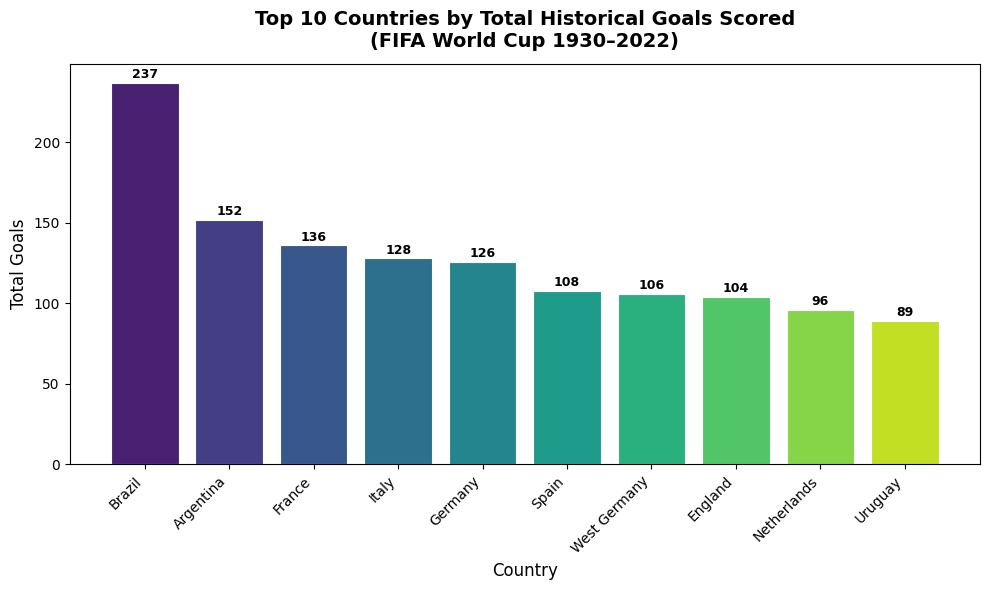


✅ Saved: top10_goals.png


In [8]:
# ── Top 10 Countries by Total Historical Goals Scored ────────────────────────
# Home goals scored
home_goals = matches.groupby('home_team')['home_score'].sum().rename('goals')
# Away goals scored
away_goals = matches.groupby('away_team')['away_score'].sum().rename('goals')
# Total goals per country
total_goals = (home_goals.add(away_goals, fill_value=0)
               .sort_values(ascending=False)
               .head(10))

print('Top 10 Countries by Total Goals Scored:')
print(total_goals.to_string())

colors = sns.color_palette('viridis', 10)
plt.figure(figsize=(10, 6))
bars = plt.bar(total_goals.index, total_goals.values, color=colors, edgecolor='white', linewidth=0.8)
plt.title('Top 10 Countries by Total Historical Goals Scored\n(FIFA World Cup 1930–2022)',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Goals', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
# Add value labels on bars
for bar, val in zip(bars, total_goals.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{int(val)}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('top10_goals.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Saved: top10_goals.png')

## Step 4: Custom Feature Engineering

**Feature Rationale:**

1. **`rank_diff`** = `away_rank − home_rank` — A positive value means the home team is ranked better (lower rank number = better). Captures the relative ranking advantage between two teams.

2. **`points_diff`** = `home_points − away_points` — Difference in FIFA points, reflecting recent form and overall strength gap. A higher positive value favours the home team.

3. **`home_team_win_rate`** — Expanding mean of home wins (win=1, other=0) per home team, computed in chronological order. This is a rolling/expanding statistic computed **before each match** (shift by 1) to prevent data leakage.

4. **`away_team_win_rate`** — Same logic but for away wins.

5. **`tournament_experience`** — Number of World Cup tournaments each team has previously participated in as of that match's year. Derived from `matches_1930_2022.csv` match history (unique years per team up to the current Year). Captures whether a team is a seasoned World Cup participant or a newcomer.

In [9]:
# ── Sort matches chronologically first ───────────────────────────────────────
matches = matches.sort_values('Year').reset_index(drop=True)

# ── Feature 1: rank_diff ──────────────────────────────────────────────────────
matches['rank_diff'] = matches['away_rank'] - matches['home_rank']

# ── Feature 2: points_diff ────────────────────────────────────────────────────
matches['points_diff'] = matches['home_points'] - matches['away_points']

# ── Features 3 & 4: Rolling win rates (no data leakage) ──────────────────────
# Create binary win indicators
matches['home_win_flag'] = (matches['Match_Result'] == 0).astype(int)  # home team won
matches['away_win_flag'] = (matches['Match_Result'] == 1).astype(int)  # away team won

# Compute expanding (cumulative) win rate per team — shifted by 1 to avoid leakage
matches['home_team_win_rate'] = (
    matches.groupby('home_team')['home_win_flag']
    .transform(lambda x: x.shift(1).expanding().mean())
)

matches['away_team_win_rate'] = (
    matches.groupby('away_team')['away_win_flag']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# ── Feature 5: Tournament Experience ─────────────────────────────────────────
# For each match, count how many distinct World Cup years BEFORE the current year
# the team has appeared in.
# Build cumulative appearance count per team per year
all_years = sorted(matches['Year'].unique())

# Build map: (team, year) -> number of previous tournaments
home_appearances = matches[['home_team', 'Year']].rename(columns={'home_team': 'team'})
away_appearances = matches[['away_team', 'Year']].rename(columns={'away_team': 'team'})
all_appearances  = pd.concat([home_appearances, away_appearances]).drop_duplicates()

# For each team, get sorted list of years they appeared
team_year_count = {}
for team, grp in all_appearances.groupby('team'):
    years_sorted = sorted(grp['Year'].unique())
    for i, yr in enumerate(years_sorted):
        team_year_count[(team, yr)] = i  # number of PREVIOUS tournaments (0 = debut)

matches['home_experience'] = matches.apply(
    lambda r: team_year_count.get((r['home_team'], r['Year']), 0), axis=1
)
matches['away_experience'] = matches.apply(
    lambda r: team_year_count.get((r['away_team'], r['Year']), 0), axis=1
)
matches['experience_diff'] = matches['home_experience'] - matches['away_experience']

print('Feature engineering complete.')
feat_cols = ['rank_diff', 'points_diff', 'home_team_win_rate', 'away_team_win_rate',
             'home_experience', 'away_experience', 'experience_diff']
print('\nFeature preview (first 5 rows):')
display(matches[feat_cols].head())

Feature engineering complete.

Feature preview (first 5 rows):


,rank_diff,points_diff,home_team_win_rate,away_team_win_rate,home_experience,away_experience,experience_diff
0,9.0,114.89,NaN,NaN,0,0,0
1,-11.0,-135.17,NaN,NaN,0,0,0
2,92.0,446.62,1.0,NaN,0,0,0
3,13.0,146.40,NaN,NaN,0,0,0
4,26.0,264.27,1.0,NaN,0,0,0


In [10]:
# ── Check NaN values in feature columns ──────────────────────────────────────
all_feat_cols = ['home_rank', 'away_rank', 'home_points', 'away_points',
                 'rank_diff', 'points_diff', 'home_team_win_rate',
                 'away_team_win_rate', 'experience_diff']

nan_check = matches[all_feat_cols].isnull().sum()
print('NaN counts per feature:')
print(nan_check)

# Fill remaining NaNs (from first matches, shift creates NaN) with column medians
for col in all_feat_cols:
    med = matches[col].median()
    n_filled = matches[col].isnull().sum()
    if n_filled > 0:
        print(f'  Filling {n_filled} NaN in "{col}" with median={med:.4f}')
    matches[col] = matches[col].fillna(med)

print('\n✅ All feature NaNs filled with column medians.')
print('Final NaN check:', matches[all_feat_cols].isnull().sum().sum(), 'NaN values remaining.')

NaN counts per feature:
home_rank              0
away_rank              0
home_points            0
away_points            0
rank_diff              0
points_diff            0
home_team_win_rate    82
away_team_win_rate    86
experience_diff        0
dtype: int64
  Filling 82 NaN in "home_team_win_rate" with median=0.7143
  Filling 86 NaN in "away_team_win_rate" with median=0.0667

✅ All feature NaNs filled with column medians.
Final NaN check: 0 NaN values remaining.


## Step 5: Temporal Train/Test Split

In [11]:
# ── Define feature columns and target ────────────────────────────────────────
FEATURE_COLS = [
    'home_rank', 'away_rank', 'home_points', 'away_points',
    'rank_diff', 'points_diff',
    'home_team_win_rate', 'away_team_win_rate',
    'experience_diff'   # 5th custom feature
]
TARGET_COL = 'Match_Result'

# ── Temporal split: NO shuffle — chronological only ──────────────────────────
train = matches[matches['Year'] <= 2018].copy()
test  = matches[matches['Year'] == 2022].copy()

X_train = train[FEATURE_COLS]
y_train = train[TARGET_COL]
X_test  = test[FEATURE_COLS]
y_test  = test[TARGET_COL]

print(f'Train size: {len(train)} matches  (Years 1930–2018)')
print(f'Test  size: {len(test)} matches  (Year 2022)')

print('\nClass distribution — Train:')
train_vc = y_train.value_counts().sort_index()
for k, v in train_vc.items():
    print(f'  {label_map[k]:10s}: {v:4d}  ({v/len(y_train)*100:.1f}%)')

print('\nClass distribution — Test:')
test_vc = y_test.value_counts().sort_index()
for k, v in test_vc.items():
    print(f'  {label_map[k]:10s}: {v:4d}  ({v/len(y_test)*100:.1f}%)')

Train size: 900 matches  (Years 1930–2018)
Test  size: 64 matches  (Year 2022)

Class distribution — Train:
  Home Win  :  503  (55.9%)
  Away Win  :  198  (22.0%)
  Draw      :  199  (22.1%)

Class distribution — Test:
  Home Win  :   29  (45.3%)
  Away Win  :   20  (31.2%)
  Draw      :   15  (23.4%)


## Step 6: Classification — Baseline & Advanced Models

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import joblib

def evaluate_classifier(model, X_tr, y_tr, X_te, y_te, name='Model'):
    """Train model and return dict of evaluation metrics."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    metrics = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_te, preds),
        'Precision': precision_score(y_te, preds, average='macro', zero_division=0),
        'Recall':    recall_score(y_te, preds, average='macro', zero_division=0),
        'F1-Score':  f1_score(y_te, preds, average='macro', zero_division=0),
    }
    return metrics, model, preds

results = []

### 6a. Baseline — Logistic Regression

Logistic Regression Results:
  Accuracy    : 0.5469
  Precision   : 0.3583
  Recall      : 0.4644
  F1-Score    : 0.4040


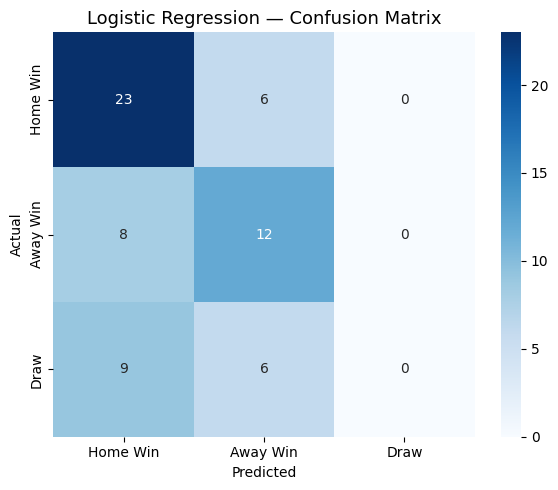

In [13]:
# ── 6a. Logistic Regression ───────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
lr_metrics, lr_model, lr_preds = evaluate_classifier(
    lr, X_train, y_train, X_test, y_test, 'Logistic Regression'
)
results.append(lr_metrics)

print('Logistic Regression Results:')
for k, v in lr_metrics.items():
    if k != 'Model':
        print(f'  {k:12s}: {v:.4f}')

# Confusion matrix
plt.figure(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label_map.values()),
            yticklabels=list(label_map.values()))
plt.title('Logistic Regression — Confusion Matrix', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### 6b. Advanced — Random Forest Classifier

Random Forest Results:
  Accuracy    : 0.5312
  Precision   : 0.4833
  Recall      : 0.4851
  F1-Score    : 0.4756


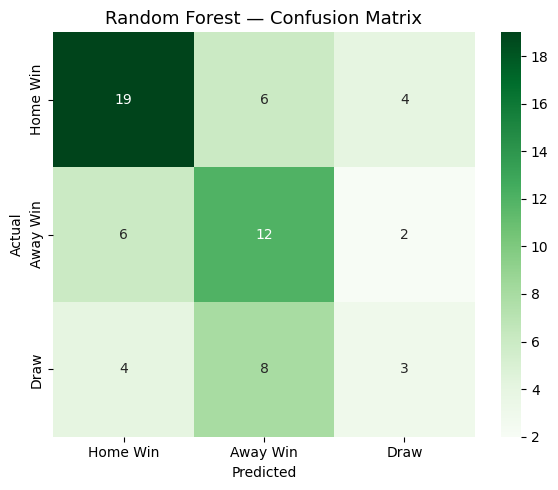

In [14]:
# ── 6b. Random Forest ─────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_metrics, rf_model, rf_preds = evaluate_classifier(
    rf, X_train, y_train, X_test, y_test, 'Random Forest'
)
results.append(rf_metrics)

print('Random Forest Results:')
for k, v in rf_metrics.items():
    if k != 'Model':
        print(f'  {k:12s}: {v:.4f}')

plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=list(label_map.values()),
            yticklabels=list(label_map.values()))
plt.title('Random Forest — Confusion Matrix', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### 6c. Bonus — XGBoost Classifier

XGBoost Results:
  Accuracy    : 0.5000
  Precision   : 0.4369
  Recall      : 0.4513
  F1-Score    : 0.4357


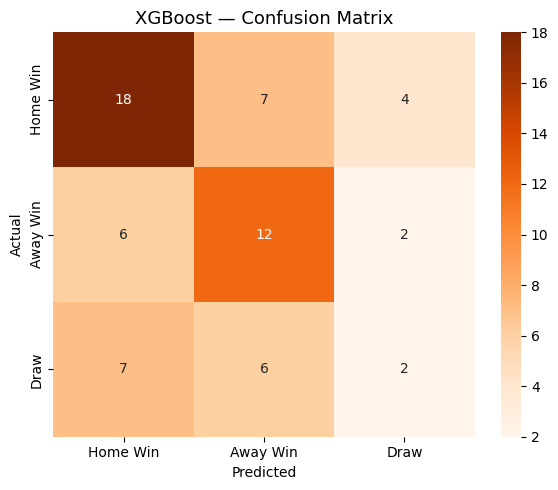


  MODEL COMPARISON TABLE


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.5469,0.3583,0.4644,0.4040
Random Forest,0.5312,0.4833,0.4851,0.4756
XGBoost,0.5000,0.4369,0.4513,0.4357


In [15]:
# ── 6c. XGBoost ───────────────────────────────────────────────────────────────
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_metrics, xgb_model, xgb_preds = evaluate_classifier(
    xgb, X_train, y_train, X_test, y_test, 'XGBoost'
)
results.append(xgb_metrics)

print('XGBoost Results:')
for k, v in xgb_metrics.items():
    if k != 'Model':
        print(f'  {k:12s}: {v:.4f}')

plt.figure(figsize=(6, 5))
cm_xgb = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=list(label_map.values()),
            yticklabels=list(label_map.values()))
plt.title('XGBoost — Confusion Matrix', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ── Side-by-side comparison table ────────────────────────────────────────────
print('\n' + '='*60)
print('  MODEL COMPARISON TABLE')
print('='*60)
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.round(4)
display(results_df)

### 6d. Hyperparameter Tuning — Random Forest GridSearchCV

In [16]:
# ── 6d. GridSearchCV on Random Forest ────────────────────────────────────────
param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [None, 10, 20],
    'min_samples_split': [2, 5]
}

print('Running GridSearchCV (this may take ~1-2 minutes)...')
gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
gs.fit(X_train, y_train)

best_rf = gs.best_estimator_
best_rf_preds = best_rf.predict(X_test)
best_rf_acc = accuracy_score(y_test, best_rf_preds)

print(f'\nBest Params: {gs.best_params_}')
print(f'Accuracy BEFORE tuning: {rf_metrics["Accuracy"]:.4f}')
print(f'Accuracy AFTER  tuning: {best_rf_acc:.4f}')

Running GridSearchCV (this may take ~1-2 minutes)...



Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy BEFORE tuning: 0.5312
Accuracy AFTER  tuning: 0.5000


### 6e. Probability Forecasting for 2026 Group Stage

In [17]:
# ── Determine best model ──────────────────────────────────────────────────────
all_results = [
    ('Logistic Regression', lr_model,  lr_metrics['Accuracy']),
    ('Random Forest',       rf_model,  rf_metrics['Accuracy']),
    ('XGBoost',             xgb_model, xgb_metrics['Accuracy']),
    ('Tuned Random Forest', best_rf,   best_rf_acc),
]
best_name, best_model, best_acc = max(all_results, key=lambda x: x[2])
print(f'Best model: {best_name}  (accuracy={best_acc:.4f})')

# Save best model
import os
os.makedirs('deployment', exist_ok=True)
joblib.dump(best_model, 'deployment/model.pkl')
print('✅ Best model saved to deployment/model.pkl')

Best model: Logistic Regression  (accuracy=0.5469)
✅ Best model saved to deployment/model.pkl


In [18]:
# ── 6e. Probability Forecasting for 2026 ─────────────────────────────────────
# Take first 10 group-stage fixtures
fixtures_2026 = schedule[schedule['Round'] == 'Group stage'].head(10).copy()

# Prepare rank26 lookup
rank26_lookup = rank26[['team', 'rank', 'points']].copy()

# Merge 2026 rankings for home teams
fixtures_2026 = fixtures_2026.merge(
    rank26_lookup.rename(columns={'team': 'home_team', 'rank': 'home_rank', 'points': 'home_points'}),
    on='home_team', how='left'
)

# Merge 2026 rankings for away teams
fixtures_2026 = fixtures_2026.merge(
    rank26_lookup.rename(columns={'team': 'away_team', 'rank': 'away_rank', 'points': 'away_points'}),
    on='away_team', how='left'
)

# Fill missing ranks/points with medians from rank26
med_rank26   = rank26_lookup['rank'].median()
med_points26 = rank26_lookup['points'].median()
fixtures_2026['home_rank']   = fixtures_2026['home_rank'].fillna(med_rank26)
fixtures_2026['away_rank']   = fixtures_2026['away_rank'].fillna(med_rank26)
fixtures_2026['home_points'] = fixtures_2026['home_points'].fillna(med_points26)
fixtures_2026['away_points'] = fixtures_2026['away_points'].fillna(med_points26)

# Compute derived features
fixtures_2026['rank_diff']   = fixtures_2026['away_rank'] - fixtures_2026['home_rank']
fixtures_2026['points_diff'] = fixtures_2026['home_points'] - fixtures_2026['away_points']

# Use final historical win rates (last computed value per team from matches)
final_home_wr = matches.groupby('home_team')['home_team_win_rate'].last().to_dict()
final_away_wr = matches.groupby('away_team')['away_team_win_rate'].last().to_dict()
global_home_wr_med = matches['home_team_win_rate'].median()
global_away_wr_med = matches['away_team_win_rate'].median()

fixtures_2026['home_team_win_rate'] = fixtures_2026['home_team'].map(final_home_wr).fillna(global_home_wr_med)
fixtures_2026['away_team_win_rate'] = fixtures_2026['away_team'].map(final_away_wr).fillna(global_away_wr_med)

# Tournament experience for 2026 teams (count prior World Cups)
team_max_exp = {team: max([cnt for (t, yr), cnt in team_year_count.items() if t == team], default=0)
                for team in set(matches['home_team'].tolist() + matches['away_team'].tolist())}
fixtures_2026['home_experience'] = fixtures_2026['home_team'].map(team_max_exp).fillna(0)
fixtures_2026['away_experience'] = fixtures_2026['away_team'].map(team_max_exp).fillna(0)
fixtures_2026['experience_diff'] = fixtures_2026['home_experience'] - fixtures_2026['away_experience']

# Predict probabilities
X_2026 = fixtures_2026[FEATURE_COLS]
probs  = best_model.predict_proba(X_2026)

# Build output DataFrame
# Class order: 0=Home Win, 1=Away Win, 2=Draw
classes = best_model.classes_  # [0, 1, 2]
home_win_idx = list(classes).index(0)
away_win_idx = list(classes).index(1)
draw_idx     = list(classes).index(2)

forecast_df = pd.DataFrame({
    'Home Team':    fixtures_2026['home_team'].values,
    'Away Team':    fixtures_2026['away_team'].values,
    'Home Win %':   (probs[:, home_win_idx] * 100).round(1),
    'Away Win %':   (probs[:, away_win_idx] * 100).round(1),
    'Draw %':       (probs[:, draw_idx]     * 100).round(1),
})

print('\n2026 Group Stage — Win/Draw Probability Forecast (Top 10 Fixtures):')
print('='*70)
display(forecast_df)

# Save forecast
forecast_df.to_csv('data/forecast_2026.csv', index=False)
print('\n✅ Forecast saved to data/forecast_2026.csv')


2026 Group Stage — Win/Draw Probability Forecast (Top 10 Fixtures):


,Home Team,Away Team,Home Win %,Away Win %,Draw %
0,Mexico,South Africa,68.1,7.3,24.7
1,South Korea,Czechia,55.7,14.5,29.8
2,Canada,Bosnia-Herzegovina,31.2,32.3,36.5
3,United States,Paraguay,49.4,22.8,27.9
4,Qatar,Switzerland,10.4,68.2,21.4
5,Brazil,Morocco,71.8,7.8,20.4
6,Haiti,Scotland,45.8,30.0,24.2
7,Australia,Turkey,31.9,37.0,31.1
8,Germany,Curaçao,75.8,5.8,18.4
9,Netherlands,Japan,51.1,24.2,24.8



✅ Forecast saved to data/forecast_2026.csv


## Step 7: Regression — Total Goals Prediction

Random Forest Regressor — Total Goals Prediction
  RMSE: 1.9020
  MAE:  1.4313


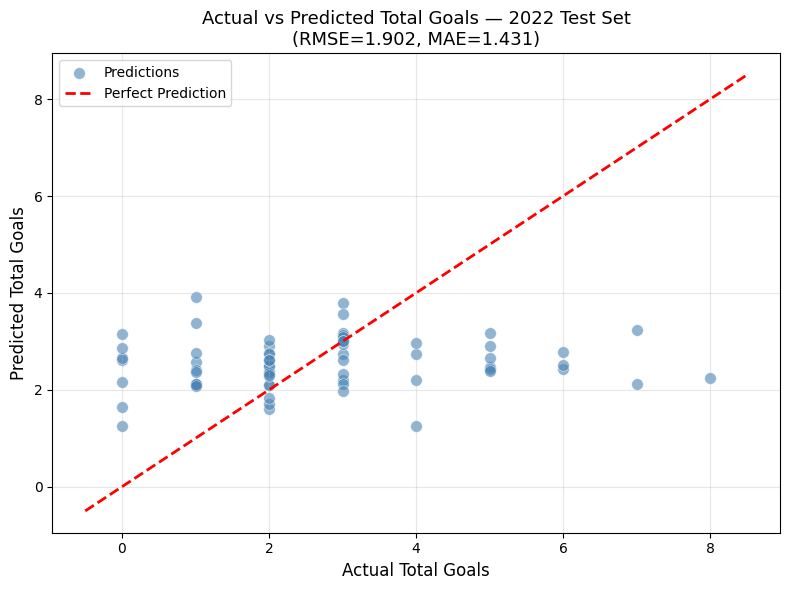

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── Create regression target ──────────────────────────────────────────────────
matches['total_goals'] = matches['home_score'] + matches['away_score']

y_train_reg = train['home_score'].values + train['away_score'].values
y_test_reg  = test['home_score'].values  + test['away_score'].values

# ── Train Random Forest Regressor ─────────────────────────────────────────────
rfr = RandomForestRegressor(n_estimators=200, random_state=42)
rfr.fit(X_train, y_train_reg)
y_pred_reg = rfr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
mae  = mean_absolute_error(y_test_reg, y_pred_reg)

print(f'Random Forest Regressor — Total Goals Prediction')
print(f'  RMSE: {rmse:.4f}')
print(f'  MAE:  {mae:.4f}')

# ── Scatter plot: Actual vs Predicted ─────────────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.6, edgecolors='white',
            linewidth=0.5, s=70, color='steelblue', label='Predictions')
min_val = min(y_test_reg.min(), y_pred_reg.min()) - 0.5
max_val = max(y_test_reg.max(), y_pred_reg.max()) + 0.5
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Total Goals', fontsize=12)
plt.ylabel('Predicted Total Goals', fontsize=12)
plt.title(f'Actual vs Predicted Total Goals — 2022 Test Set\n(RMSE={rmse:.3f}, MAE={mae:.3f})',
          fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8 (Bonus): K-Means Team Clustering

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ── Aggregate per-team statistics ─────────────────────────────────────────────
# Home stats
home_stats = matches.groupby('home_team').agg(
    home_goals_scored =('home_score', 'mean'),
    home_goals_conceded=('away_score', 'mean'),
    home_wins          =('home_win_flag', 'sum'),
    home_matches       =('home_team', 'count')
).reset_index().rename(columns={'home_team': 'team'})

# Away stats
away_stats = matches.groupby('away_team').agg(
    away_goals_scored =('away_score', 'mean'),
    away_goals_conceded=('home_score', 'mean'),
    away_wins          =('away_win_flag', 'sum'),
    away_matches       =('away_team', 'count')
).reset_index().rename(columns={'away_team': 'team'})

# Combine
team_stats = home_stats.merge(away_stats, on='team', how='outer').fillna(0)
team_stats['avg_goals_scored']   = (team_stats['home_goals_scored'] + team_stats['away_goals_scored']) / 2
team_stats['avg_goals_conceded'] = (team_stats['home_goals_conceded'] + team_stats['away_goals_conceded']) / 2
team_stats['total_wins']         = team_stats['home_wins'] + team_stats['away_wins']
team_stats['total_matches']      = team_stats['home_matches'] + team_stats['away_matches']
team_stats['win_rate']           = team_stats['total_wins'] / team_stats['total_matches']

cluster_feats = ['avg_goals_scored', 'avg_goals_conceded', 'win_rate', 'total_matches']
team_cluster_df = team_stats[['team'] + cluster_feats].dropna()

print(f'Teams with sufficient data for clustering: {len(team_cluster_df)}')
display(team_cluster_df.head())

Teams with sufficient data for clustering: 86


,team,avg_goals_scored,avg_goals_conceded,win_rate,total_matches
0,Algeria,0.988095,1.476190,0.230769,13.0
1,Angola,0.250000,0.750000,0.000000,3.0
2,Argentina,1.559906,1.267972,0.534091,88.0
3,Australia,0.875000,1.812500,0.200000,20.0
4,Austria,1.558824,1.529412,0.413793,29.0


In [21]:
# ── Standardize and run K-Means k=3 ──────────────────────────────────────────
scaler     = StandardScaler()
X_cluster  = scaler.fit_transform(team_cluster_df[cluster_feats])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
team_cluster_df = team_cluster_df.copy()
team_cluster_df['cluster'] = kmeans.fit_predict(X_cluster)

# Assign semantic labels based on mean win_rate per cluster
cluster_win_rates = team_cluster_df.groupby('cluster')['win_rate'].mean().sort_values(ascending=False)
cluster_labels_ordered = cluster_win_rates.index.tolist()  # [highest, mid, lowest]
cluster_label_map = {
    cluster_labels_ordered[0]: 'Elite Contenders',
    cluster_labels_ordered[1]: 'Mid-Table',
    cluster_labels_ordered[2]: 'Underdogs',
}
team_cluster_df['cluster_name'] = team_cluster_df['cluster'].map(cluster_label_map)

print('Cluster Summary (by mean win_rate):')
print(team_cluster_df.groupby('cluster_name')[cluster_feats].mean().round(3))

print('\nElite Contenders:')
elite = team_cluster_df[team_cluster_df['cluster_name'] == 'Elite Contenders']['team'].sort_values().tolist()
print(elite)

Cluster Summary (by mean win_rate):
                  avg_goals_scored  avg_goals_conceded  win_rate  \
cluster_name                                                       
Elite Contenders             1.694               1.285     0.469   
Mid-Table                    1.086               1.481     0.270   
Underdogs                    0.406               2.433     0.021   

                  total_matches  
cluster_name                     
Elite Contenders         52.000  
Mid-Table                15.975  
Underdogs                 4.043  

Elite Contenders:
['Argentina', 'Austria', 'Belgium', 'Brazil', 'Croatia', 'Czechoslovakia', 'England', 'France', 'Germany', 'Hungary', 'Italy', 'Mexico', 'Netherlands', 'Poland', 'Portugal', 'Soviet Union', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 'Uruguay', 'West Germany', 'Yugoslavia']


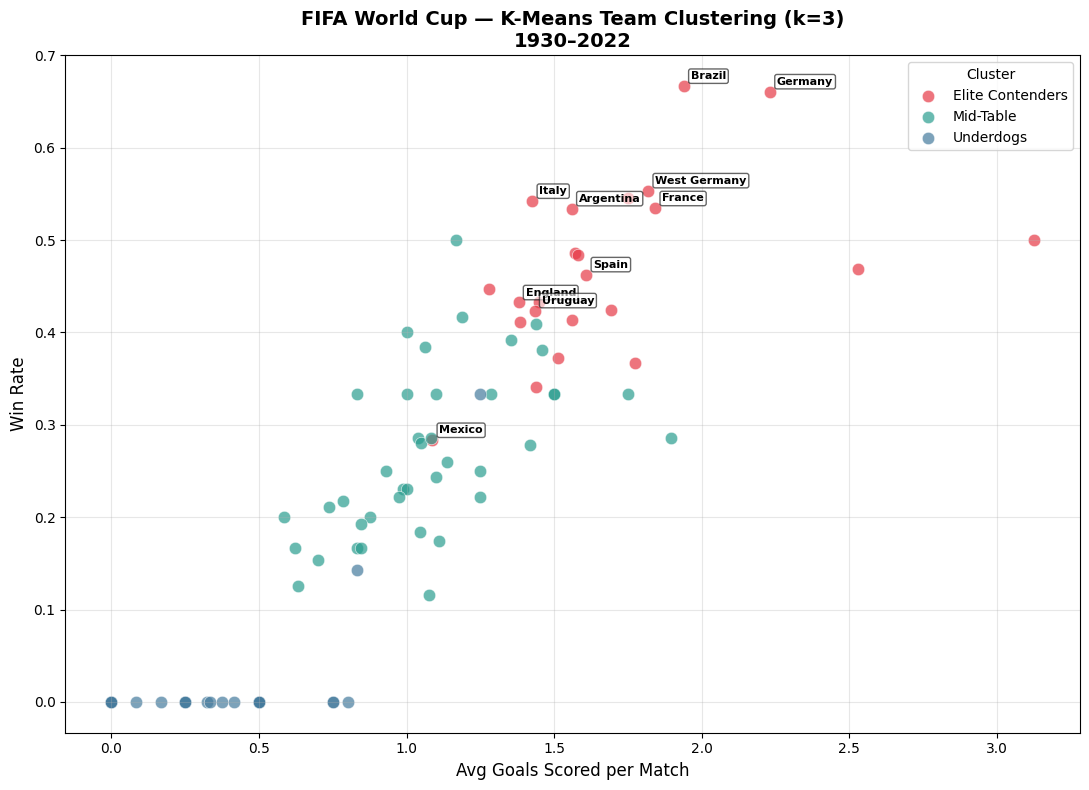


✅ Saved: team_clusters.png


In [22]:
# ── Cluster Scatter Plot ──────────────────────────────────────────────────────
color_map = {'Elite Contenders': '#e63946', 'Mid-Table': '#2a9d8f', 'Underdogs': '#457b9d'}
top10_by_matches = team_cluster_df.nlargest(10, 'total_matches')['team'].tolist()

plt.figure(figsize=(11, 8))
for label, grp in team_cluster_df.groupby('cluster_name'):
    plt.scatter(grp['avg_goals_scored'], grp['win_rate'],
                label=label, color=color_map[label],
                s=80, alpha=0.7, edgecolors='white', linewidth=0.5)

# Annotate top 10 teams
for _, row in team_cluster_df[team_cluster_df['team'].isin(top10_by_matches)].iterrows():
    plt.annotate(row['team'],
                 xy=(row['avg_goals_scored'], row['win_rate']),
                 xytext=(5, 5), textcoords='offset points',
                 fontsize=8, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))

plt.xlabel('Avg Goals Scored per Match', fontsize=12)
plt.ylabel('Win Rate', fontsize=12)
plt.title('FIFA World Cup — K-Means Team Clustering (k=3)\n1930–2022', fontsize=14, fontweight='bold')
plt.legend(title='Cluster', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('team_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Saved: team_clusters.png')

## Step 9 (Bonus): Streamlit Deployment

In [23]:
# ── Save supporting data for the Streamlit app ────────────────────────────────
# Save rank26 with consistent team names
rank26.to_csv('data/rank26_clean.csv', index=False)

# Save final win rates for all teams
win_rate_df = pd.DataFrame({
    'team': list(final_home_wr.keys()),
    'home_win_rate': list(final_home_wr.values())
})
away_wr_df = pd.DataFrame({
    'team': list(final_away_wr.keys()),
    'away_win_rate': list(final_away_wr.values())
})
wr_df = win_rate_df.merge(away_wr_df, on='team', how='outer')
wr_df.to_csv('data/team_win_rates.csv', index=False)

# Save tournament experience data
exp_records = [{'team': t, 'experience': v}
               for (t, yr), v in team_year_count.items()]
exp_df = pd.DataFrame(exp_records).groupby('team')['experience'].max().reset_index()
exp_df.to_csv('data/team_experience.csv', index=False)

# Save feature column names and global medians for the app
meta = {
    'feature_cols': FEATURE_COLS,
    'median_rank':   float(med_rank26),
    'median_points': float(med_points26),
    'global_home_wr_med': float(global_home_wr_med),
    'global_away_wr_med': float(global_away_wr_med),
    'best_model_name': best_name,
    'best_model_accuracy': float(best_acc),
    'elite_contenders': elite
}
import json
with open('data/app_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('✅ Supporting files saved for Streamlit app:')
print('   data/rank26_clean.csv')
print('   data/team_win_rates.csv')
print('   data/team_experience.csv')
print('   data/app_meta.json')
print('   deployment/model.pkl')
print(f'\nBest model: {best_name}  |  Test Accuracy: {best_acc:.4f}')

✅ Supporting files saved for Streamlit app:
   data/rank26_clean.csv
   data/team_win_rates.csv
   data/team_experience.csv
   data/app_meta.json
   deployment/model.pkl

Best model: Logistic Regression  |  Test Accuracy: 0.5469
